In [1]:
import numpy as np
import pandas as pd
import csv
import random
from sklearn.linear_model import LogisticRegression
import sys
import os

sys.path.insert(0, "../../../Modules")

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 10)
random.seed(0)
np.random.seed(0)

from utils import *

enc = 'utf-8'

In [2]:
import warnings
warnings.filterwarnings("ignore")

In [3]:
NUTS0 = 'GR'
NUTS2 = 'Thessaly'

In [4]:
YEAR = 2023

In [5]:
#class ratio must be [0,1]
#lower number means more aggressive spliting towards the higher classes

NUMBER_OF_CLASSES = 10
CLASS_RATIO = 0.65

In [6]:
base_path = f'../../data/{NUTS2}/results/'

In [7]:
file_list = os.listdir(base_path)
file_list.sort()
file_list

['GR_Thessaly_Results_2010-2022.csv',
 'GR_Thessaly_Results_2023-August-1st.csv',
 'GR_Thessaly_Results_2023-August-1st_(new).csv',
 'GR_Thessaly_Results_2023-August-2nd_(new).csv',
 'GR_Thessaly_Results_2023-July-1st.csv',
 'GR_Thessaly_Results_2023-July-1st_(new).csv',
 'GR_Thessaly_Results_2023-July-2nd.csv',
 'GR_Thessaly_Results_2023-July-2nd_(new).csv',
 'GR_Thessaly_Results_2023-June-1st.csv',
 'GR_Thessaly_Results_2023-June-1st_(new).csv',
 'GR_Thessaly_Results_2023-June-2nd.csv',
 'GR_Thessaly_Results_2023-June-2nd_(new).csv',
 'GR_Thessaly_Results_2023-May-1st.csv',
 'GR_Thessaly_Results_2023-May-1st_(new).csv',
 'GR_Thessaly_Results_2023-May-2nd.csv',
 'GR_Thessaly_Results_2023-May-2nd_(new).csv']

In [8]:
file = file_list[0]

data = pd.read_csv(f'{base_path}/{file}', encoding='utf-8')
data.drop(columns=['x', 'y'], inplace=True)
data.rename(columns={"probability": "score", "municipality": "lau1"}, inplace=True)


In [9]:
data

,lau1,day,month,year,case,score
0,λαρισαιων,16,8,2012,0,9.947195e-01
1,λαρισαιων,16,7,2012,0,9.946419e-01
2,λαρισαιων,1,8,2012,0,9.920437e-01
3,τυρναβου,16,8,2012,0,9.903039e-01
4,τυρναβου,16,7,2012,0,9.863118e-01
...,...,...,...,...,...,...
3895,ζαγορας μουρεσιου,1,5,2014,0,5.856035e-07
3896,λιμνης πλαστηρα,1,5,2016,0,4.937999e-07
3897,αλοννησου,1,5,2011,0,3.692605e-07
3898,αλοννησου,1,5,2015,0,2.272989e-07


In [10]:
data_og = data.copy()

In [11]:
np.sort(data.month.unique())

array([ 5,  6,  7,  8,  9, 10], dtype=int64)

In [12]:
np.sort(data.year.unique())

array([2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020,
       2021, 2022], dtype=int64)

In [13]:
zero_score = {'lau1': 'αγνωστη', 'day': 0, 'month': 0, 'year': 0, 'case': 0, 'score': 0}
one_score = {'lau1': 'αγνωστη', 'day': 0, 'month': 0, 'year': 0, 'case': 0, 'score': 1}

In [14]:
data = data.append(zero_score, ignore_index = True)
data = data.append(one_score, ignore_index = True)

In [15]:
data

,lau1,day,month,year,case,score
0,λαρισαιων,16,8,2012,0,9.947195e-01
1,λαρισαιων,16,7,2012,0,9.946419e-01
2,λαρισαιων,1,8,2012,0,9.920437e-01
3,τυρναβου,16,8,2012,0,9.903039e-01
4,τυρναβου,16,7,2012,0,9.863118e-01
...,...,...,...,...,...,...
3897,αλοννησου,1,5,2011,0,3.692605e-07
3898,αλοννησου,1,5,2015,0,2.272989e-07
3899,αλοννησου,1,5,2017,0,2.085557e-07
3900,αγνωστη,0,0,0,0,0.000000e+00


In [16]:
data_sorted = data.sort_values(by='score', ascending=True)

In [17]:
data_sorted.reset_index(drop = True, inplace = True)

In [18]:
data_sorted

,lau1,day,month,year,case,score
0,αγνωστη,0,0,0,0,0.000000e+00
1,αλοννησου,1,5,2017,0,2.085557e-07
2,αλοννησου,1,5,2015,0,2.272989e-07
3,αλοννησου,1,5,2011,0,3.692605e-07
4,λιμνης πλαστηρα,1,5,2016,0,4.937999e-07
...,...,...,...,...,...,...
3897,τυρναβου,16,8,2012,0,9.903039e-01
3898,λαρισαιων,1,8,2012,0,9.920437e-01
3899,λαρισαιων,16,7,2012,0,9.946419e-01
3900,λαρισαιων,16,8,2012,0,9.947195e-01


<AxesSubplot:>

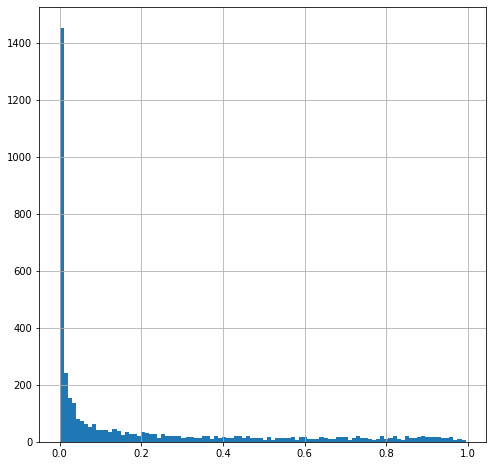

In [19]:
data_og.score.hist(bins = 100, figsize = (8,8))

In [20]:
number_of_observations = len(data_sorted)

In [21]:
r_sum = 0

for i in range(NUMBER_OF_CLASSES):
    r_sum = r_sum + CLASS_RATIO**i

x = round(number_of_observations/r_sum)

x

1384

In [22]:
temp_x = x
total_obs = 0
obs = []

for c in range(NUMBER_OF_CLASSES):
    total_obs = total_obs + temp_x
    obs.append(temp_x)
    print(f'Class {c}: {temp_x} observations')
    temp_x = round(temp_x*CLASS_RATIO)
    
print(f'\nTotal Observations: {total_obs}')

Class 0: 1384 observations
Class 1: 900 observations
Class 2: 585 observations
Class 3: 380 observations
Class 4: 247 observations
Class 5: 161 observations
Class 6: 105 observations
Class 7: 68 observations
Class 8: 44 observations
Class 9: 29 observations

Total Observations: 3903


In [23]:
bins = []
sum = 0
for index in obs:
    sum = sum + index
    try:
        bin_lim = data_sorted.loc[sum, 'score']
    except KeyError:
        bin_lim = data_sorted.loc[number_of_observations-1, 'score']
    bins.append(bin_lim)

bins.insert(0,0)
bins[-1] = 1 

In [24]:
data_og['risk_class'] = pd.cut(data_og['score'], bins=bins, labels=False, include_lowest=True)

data_og.risk_class.value_counts().sort_index()

0    1384
1     900
2     585
3     380
4     247
5     161
6     105
7      68
8      44
9      26
Name: risk_class, dtype: int64

In [25]:
bins_formatted = [ '%.4f' % elem for elem in bins]
print(bins_formatted)

['0.0000', '0.0080', '0.0859', '0.2731', '0.5104', '0.7000', '0.8197', '0.8909', '0.9297', '0.9610', '1.0000']


In [26]:
class9 = data_og.loc[data_og.risk_class == 9]
class8 = data_og.loc[data_og.risk_class == 8]
class7 = data_og.loc[data_og.risk_class == 7]
class6 = data_og.loc[data_og.risk_class == 6]
class5 = data_og.loc[data_og.risk_class == 5]
class4 = data_og.loc[data_og.risk_class == 4]
class3 = data_og.loc[data_og.risk_class == 3]
class2 = data_og.loc[data_og.risk_class == 2]
class1 = data_og.loc[data_og.risk_class == 1]
class0 = data_og.loc[data_og.risk_class == 0]

In [27]:
means = []

means.append(class0.case.mean())
means.append(class1.case.mean())
means.append(class2.case.mean())
means.append(class3.case.mean())
means.append(class4.case.mean())
means.append(class5.case.mean())
means.append(class6.case.mean())
means.append(class7.case.mean())
means.append(class8.case.mean())
means.append(class9.case.mean())

In [28]:
means

[0.0,
 0.0033333333333333335,
 0.03247863247863248,
 0.042105263157894736,
 0.044534412955465584,
 0.09316770186335403,
 0.0761904761904762,
 0.10294117647058823,
 0.13636363636363635,
 0.11538461538461539]

In [29]:
class_bins = []

In [30]:
class_very_low = class0
class_very_low.reset_index(drop = True, inplace = True)
class_very_low

print(f'Threashold: ({class_very_low.score.min():.3f} - {class_very_low.score.max():.3f})')
print(f'Samples: {len(class_very_low)}')
print(f'% Samples: {len(class_very_low)/len(data_og) * 100:.3f} %')
print(f'Accuracy: {class_very_low.case.mean() * 100 :.2f} %')

class_bins.append(0)

Threashold: (0.000 - 0.008)
Samples: 1384
% Samples: 35.487 %
Accuracy: 0.00 %


In [31]:
class_low = class1
class_low.reset_index(drop = True, inplace = True)
class_low

print(f'Threashold: ({class_low.score.min():.3f} - {class_low.score.max():.3f})')
print(f'Samples: {len(class_low)}')
print(f'% Samples: {len(class_low)/len(data_og) * 100:.3f} %')
print(f'Accuracy: {class_low.case.mean() * 100 :.2f} %')

class_bins.append(class_low.score.min())

Threashold: (0.008 - 0.086)
Samples: 900
% Samples: 23.077 %
Accuracy: 0.33 %


In [32]:
class_mid = pd.concat([class2, class3])
class_mid.reset_index(drop = True, inplace = True)
class_mid

print(f'Threashold: ({class_mid.score.min():.3f} - {class_mid.score.max():.3f})')
print(f'Samples: {len(class_mid)}')
print(f'% Samples: {len(class_mid)/len(data_og) * 100:.3f} %')
print(f'Accuracy: {class_mid.case.mean() * 100 :.2f} %')

class_bins.append(class_mid.score.min())

Threashold: (0.086 - 0.510)
Samples: 965
% Samples: 24.744 %
Accuracy: 3.63 %


In [33]:
class_mid_high = pd.concat([class4, class5])
class_mid_high.reset_index(drop = True, inplace = True)
class_mid_high

print(f'Threashold: ({class_mid_high.score.min():.3f} - {class_mid_high.score.max():.3f})')
print(f'Samples: {len(class_mid_high)}')
print(f'% Samples: {len(class_mid_high)/len(data_og) * 100:.3f} %')
print(f'Accuracy: {class_mid_high.case.mean() * 100 :.2f} %')

class_bins.append(class_mid_high.score.min())

Threashold: (0.511 - 0.820)
Samples: 408
% Samples: 10.462 %
Accuracy: 6.37 %


In [34]:
class_high = pd.concat([class6, class7])
class_high.reset_index(drop = True, inplace = True)
class_high

print(f'Threashold: ({class_high.score.min():.3f} - {class_high.score.max():.3f})')
print(f'Samples: {len(class_high)}')
print(f'% Samples: {len(class_high)/len(data_og) * 100:.3f} %')
print(f'Accuracy: {class_high.case.mean() * 100 :.2f} %')

class_bins.append(class_high.score.min())

Threashold: (0.820 - 0.930)
Samples: 173
% Samples: 4.436 %
Accuracy: 8.67 %


In [35]:
class_very_high = pd.concat([class8, class9])
class_very_high.reset_index(drop = True, inplace = True)
class_very_high

print(f'Threashold: ({class_very_high.score.min():.3f} - {class_very_high.score.max():.3f})')
print(f'Samples: {len(class_very_high)}')
print(f'% Samples: {len(class_very_high)/len(data_og) * 100:.3f} %')
print(f'Accuracy: {class_very_high.case.mean() * 100 :.2f} %')

class_bins.append(class_very_high.score.min())

Threashold: (0.931 - 0.995)
Samples: 70
% Samples: 1.795 %
Accuracy: 12.86 %


In [36]:
class_bins.append(1)

In [37]:
class_bins_formatted = [ '%.4f' % elem for elem in class_bins]
print(class_bins_formatted)

['0.0000', '0.0080', '0.0860', '0.5110', '0.8201', '0.9305', '1.0000']


In [38]:
bins_path = f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_Bins_{YEAR}.csv'

with open(bins_path, mode='w', newline='') as file:
    writer = csv.writer(file)
    writer.writerow(class_bins)